In [110]:
%pip install -q kagglehub

In [111]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch.utils.data as data
import torchvision
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import torchvision.models as models

import matplotlib.pyplot as plt
import numpy as np

import copy
from collections import namedtuple
import os
import random
import time

import cv2
from torch.utils.data import DataLoader,Dataset
from PIL import Image

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

namedtuple : 파이썬의 자료형. 튜플의 성질을 가지고 있어서, 인덱스와 키 값으로 모두 데이터에 접근할 수 있음

### 이미지 전처리

모델에 이미지를 넣기 전에 크기를 224×224로 맞추고 텐서로 변환한다. 학습 이미지에는 무작위 자르기와 좌우 반전을 적용해 데이터에 변화를 준다. 검증·테스트 이미지에는 무작위 변형을 적용하지 않아 같은 이미지를 일관되게 평가한다.

`mean`과 `std`는 각 색상 채널의 값을 정규화하는 데 사용한다.

In [112]:
class ImageTransform():
  def __init__(self,resize,mean,std):
    self.data_transform={
        'train' : transforms.Compose([
            transforms.RandomResizedCrop(resize,scale=(0.5,1.0)),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ]), ## 훈련 이미지 데이터에 대한 전처리
        'val' : transforms.Compose([
            transforms.Resize(resize),
            transforms.CenterCrop(resize),
            transforms.ToTensor(),
            transforms.Normalize(mean,std)
        ]), ## 검증과 테스트 이미지 데이터에 대한 전처리
    }

  def __call__(self, img, phase):
    return self.data_transform[phase](img)

In [113]:
size = 224
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)

batch_size = 32

### 데이터 준비

KaggleHub로 받은 데이터에서 `PetImages/Cat`, `PetImages/Dog` 폴더의 이미지 경로를 가져온다. 경로를 섞은 뒤 이미지 600장을 후보로 선택하고, 읽을 수 있는 이미지만 남긴다.

이후 학습 400장, 검증 100장, 테스트 10장으로 나눈다. 학습 데이터는 모델의 가중치를 업데이트하고, 검증 데이터는 학습 중 성능을 확인하며, 테스트 데이터는 마지막 예측에 사용한다.

In [114]:
import os
import random
import cv2
import kagglehub

# 1. 데이터셋 다운로드: 반환된 경로를 그대로 사용
dataset_path = kagglehub.dataset_download(
    "shaunthesheep/microsoft-catsvsdogs-dataset"
)
print("다운로드 경로:", dataset_path)

# 2. 실제 폴더 구조에 맞춰 Cat/Dog 경로 생성
cat_directory = os.path.join(dataset_path, "PetImages", "Cat")
dog_directory = os.path.join(dataset_path, "PetImages", "Dog")

print("Cat 폴더 존재:", os.path.isdir(cat_directory))
print("Dog 폴더 존재:", os.path.isdir(dog_directory))

# 3. 이미지 파일 경로 모으기
extensions = (".jpg", ".jpeg", ".png")

cat_images_filepaths = [
    os.path.join(cat_directory, f)
    for f in os.listdir(cat_directory)
    if f.lower().endswith(extensions)
]

dog_images_filepaths = [
    os.path.join(dog_directory, f)
    for f in os.listdir(dog_directory)
    if f.lower().endswith(extensions)
]

images_filepaths = cat_images_filepaths + dog_images_filepaths


Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.
다운로드 경로: /kaggle/input/microsoft-catsvsdogs-dataset
Cat 폴더 존재: True
Dog 폴더 존재: True


In [115]:
# 4. Cat/Dog가 섞이도록 먼저 셔플한 뒤 600장 선택
random.seed(42)
random.shuffle(images_filepaths)
candidate_filepaths = images_filepaths[:600]

# 5. 읽을 수 있는 이미지만 남기기
correct_images_filepaths = [
    image_path for image_path in candidate_filepaths
    if cv2.imread(image_path) is not None
]

if len(correct_images_filepaths) < 510:
    raise ValueError(
        f"분할에 필요한 이미지 510장 중 {len(correct_images_filepaths)}장만 읽혔습니다."
    )

In [116]:
# 6. 분할
train_images_filepaths = correct_images_filepaths[:400]
val_images_filepaths = correct_images_filepaths[400:500]
test_images_filepaths = correct_images_filepaths[500:510]

print(
    len(train_images_filepaths),
    len(val_images_filepaths),
    len(test_images_filepaths)
)  # 400 100 10

400 100 10


### Dataset과 DataLoader

`Dataset`은 이미지 한 장을 읽고 `(이미지 텐서, 정답 라벨)`을 반환한다. 라벨은 파일명이 아니라 상위 폴더 이름으로 결정한다: `Cat = 0`, `Dog = 1`.

`DataLoader`는 이렇게 만든 데이터를 배치 단위로 묶는다. 학습 배치는 순서를 섞고(`shuffle=True`), 검증 배치는 섞지 않는다.

In [117]:
class DogvsCatDataset(Dataset):
  def __init__(self, file_list, transforms=None, phase='train'):
    self.file_list = file_list
    self.transforms = transforms
    self.phase = phase

  def __len__(self):
    return len(self.file_list)

  def __getitem__(self, idx):
    img_path = self.file_list[idx]
    img = Image.open(img_path).convert('RGB')
    img_transformed = self.transforms(img, self.phase)

    # 파일명이 아니라 바로 위 폴더 이름(Cat 또는 Dog)을 확인
    category = os.path.basename(os.path.dirname(img_path)).lower()

    if category == 'cat':
        label = 0
    elif category == 'dog':
        label = 1
    else:
        raise ValueError(f"알 수 없는 이미지 폴더: {img_path}")

    return img_transformed, label

In [118]:
train_dataset = DogvsCatDataset(train_images_filepaths,
                                transforms = ImageTransform(size, mean, std),
                                phase='train')
val_dataset = DogvsCatDataset(val_images_filepaths,
                              transforms = ImageTransform(size, mean, std),
                              phase='val')

In [119]:
train_iterator = DataLoader(train_dataset, batch_size = batch_size, shuffle=True)
val_iterator = DataLoader(val_dataset, batch_size = batch_size, shuffle=False)
dataloader_dict = {'train':train_iterator, 'val':val_iterator}

batch_iterator = iter(train_iterator)
inputs, labels = next(batch_iterator)
print(inputs.size())
print(labels)

torch.Size([32, 3, 224, 224])
tensor([1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
        1, 1, 0, 0, 0, 0, 0, 1])


### ResNet 구조

ResNet 블록은 입력 `x`에 합성곱 결과 `F(x)`를 더하는 잔차 연결을 사용한다: `출력 = F(x) + x`. 입력과 출력의 채널 수 또는 크기가 다르면 `downsample`로 더할 수 있는 형태를 맞춘다.

이 노트북에서 실제 생성하는 ResNet-50은 `BasicBlock`이 아닌 `Bottleneck`을 사용한다. 네 개의 stage에 Bottleneck 블록을 각각 3개, 4개, 6개, 3개 쌓는다.

In [120]:
class BasicBlock(nn.Module):
  expansion = 1

  def __init__(self, in_channels, out_channels, stride=1, downsample=False):
    super().__init()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                           stride=stride, padding=1, bias=False)  ## 3*3 conv
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                           stride=1, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)
    self.relu = nn.ReLU(inplace=True)

    if downsample:
      conv = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                       stride=stride, bias=False)
      bn = nn.BatchNorm2d(out_channels)
      downsample = nn.Sequential(conv, bn)
    else:
      downsample=None

    self.downsample = downsample


  def forward(self, x):
    i = x
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.bn2(x)
    x = self.conv3(x)
    x = self.bn3(x)

    if self.downsample is not None:
      i = self.downsample(i)

    x += i
    x = self.relu(x)

    return x


In [121]:
class Bottleneck(nn. Module):
  expansion = 4
  def __init__(self, in_channels, out_channels, stride=1, downsample=False):
    super().__init__()
    self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1,
                           stride=1, bias=False)
    self.bn1 = nn.BatchNorm2d(out_channels)
    self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                           stride=stride, padding=1, bias=False)
    self.bn2 = nn.BatchNorm2d(out_channels)
    self.conv3 = nn.Conv2d(out_channels, self.expansion*out_channels,
                           kernel_size=1, stride=1, bias=False)
    self.bn3 = nn.BatchNorm2d(self.expansion*out_channels)
    self.relu = nn.ReLU(inplace=True)

    if downsample:
      conv = nn.Conv2d(in_channels, self.expansion*out_channels, kernel_size=1,
                       stride=stride, bias=False)
      bn = nn.BatchNorm2d(self.expansion*out_channels)
      downsample = nn.Sequential(conv, bn)
    else:
      downsample = None

    self.downsample = downsample

  def forward(self, x):
    i = x
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.relu(x)
    x = self.conv2(x)
    x = self.bn2(x)
    x = self.relu(x)
    x = self.conv3(x)
    x = self.bn3(x)

    if self.downsample is not None:
      i = self.downsample(i)
    x += i
    x = self.relu(x)
    return x

In [122]:
class ResNet(nn.Module):
    def __init__(self, config, output_dim, zero_init_residual=False):
        super().__init__()

        block, n_blocks, channels = config
        self.in_channels = channels[0]
        assert len(n_blocks) == len(channels) == 4


        # 입력: [batch, 3, 224, 224]
        self.conv1 = nn.Conv2d(
            3, self.in_channels,
            kernel_size=7, stride=2, padding=3, bias=False
        )
        self.bn1 = nn.BatchNorm2d(self.in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(
            kernel_size=3, stride=2, padding=1
        )

        # 네 개의 ResNet stage
        self.layer1 = self.get_resnet_layer(
            block, n_blocks[0], channels[0]
        )
        self.layer2 = self.get_resnet_layer(
            block, n_blocks[1], channels[1], stride=2
        )
        self.layer3 = self.get_resnet_layer(
            block, n_blocks[2], channels[2], stride=2
        )
        self.layer4 = self.get_resnet_layer(
            block, n_blocks[3], channels[3], stride=2
        )

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(self.in_channels, output_dim)

        # 각 residual branch의 마지막 BN을 0으로 초기화
        if zero_init_residual:
            for module in self.modules():
                if isinstance(module, Bottleneck):
                    nn.init.constant_(module.bn3.weight, 0)
                elif isinstance(module, BasicBlock):
                    nn.init.constant_(module.bn2.weight, 0)

    def get_resnet_layer(self, block, n_blocks, channels, stride=1):
      layers = []

      if self.in_channels != block.expansion * channels:
        downsample = True
      else:
        downsample = False

      layers.append(
          block(self.in_channels, channels, stride, downsample)
      )
      self.in_channels = block.expansion * channels
      for i in range(1, n_blocks):
        layers.append(
            block(block.expansion*channels, channels)
        )

      self.in_chanels = block.expansion*channels
      return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)       # 224×224 → 112×112
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)     # 112×112 → 56×56

        x = self.layer1(x)      # 56×56
        x = self.layer2(x)      # 28×28
        x = self.layer3(x)      # 14×14
        x = self.layer4(x)      # 7×7

        x = self.avgpool(x)     # 1×1
        h = x.view(x.shape[0],-1) # [batch, 마지막 채널 수]
        x = self.fc(h)
        return x, h


In [123]:
ResNetConfig = namedtuple('ResNetConfig', ['block', 'n_blocks', 'channels'])


In [124]:
resnet18_config = ResNetConfig(block=BasicBlock,
                               n_blocks=[2,2,2,2],
                               channels=[64,128,256,512])

resnet34_config = ResNetConfig(block=BasicBlock,
                               n_blocks=[3,4,6,3],
                               channels=[64,128,256,512])

In [125]:
resnet50_config = ResNetConfig(block=Bottleneck,
                               n_blocks=[3,4,6,3],
                               channels=[64,128,256,512])

resnet101_config = ResNetConfig(block=Bottleneck,
                                n_blocks=[3,4,23,3],
                                channels=[64,128,256,512])

resnet152_config = ResNetConfig(block=Bottleneck,
                                n_blocks=[3,8,36,3],
                                channels=[64,128,256,512])


In [126]:
pretrained_model = models.resnet50(pretrained=True)

In [127]:
print(pretrained_model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

### 모델 출력

마지막 특징 맵을 평균 풀링한 결과가 `h`이고, 이를 완전연결층에 통과시켜 고양이·개에 대한 점수 `x`를 만든다. 현재 모델의 반환값은 `(x, h)`이므로, 손실 함수와 정확도를 계산할 때는 첫 번째 값인 `y_pred[0]`을 사용한다.

위에서 만든 `pretrained_model`은 현재 학습 코드에 연결되어 있지 않다. 실제로 학습하는 `model = ResNet(...)`은 새로 생성한 모델이다.

In [128]:
OUTPUT_DIM = 2
model = ResNet(resnet50_config, OUTPUT_DIM)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [129]:
optimizer = optim.Adam(model.parameters(), lr = 1e-7)
criterion = nn.CrossEntropyLoss()

model = model.to(device)
criterion = criterion.to(device)

### 학습과 평가

학습할 때는 예측 점수와 정답으로 손실을 계산하고, 역전파와 `optimizer.step()`으로 가중치를 업데이트한다. 검증할 때는 `model.eval()`과 `torch.no_grad()`를 사용해 가중치를 업데이트하지 않는다.

현재 정확도 함수는 `k=2`이므로 top-1과 top-2 정확도를 반환한다. 클래스가 고양이·개 두 개뿐이라 top-2 정확도는 항상 100%다. 학습 상태는 top-1 정확도와 검증 손실을 중심으로 확인한다.

In [130]:
def calculate_topk_accuracy(y_pred, y, k=2):
  with torch.no_grad():
    batch_size= y.shape[0]
    _, top_pred = y_pred.topk(k, 1)
    top_pred = top_pred.t()
    correct = top_pred.eq(y.view(1, -1).expand_as(top_pred))
    correct_1 = correct[:1].reshape(-1).float().sum(0, keepdim=True)
    correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
    acc_1 = correct_1 / batch_size
    acc_k = correct_k / batch_size
  return acc_1, acc_k


In [131]:
def train(model, iterator, optimizer, criterion, device):
  epoch_loss = 0
  epoch_acc_1 = 0
  epoch_acc_5 = 0

  model.train()
  for (x,y) in iterator:
    x = x.to(device)
    y = y.to(device)

    optimizer.zero_grad()
    y_pred = model(x)
    loss = criterion(y_pred[0], y)
    acc_1, acc_5 = calculate_topk_accuracy(y_pred[0], y)
    loss.backward()
    optimizer.step()

    epoch_loss += loss.item()
    epoch_acc_1 += acc_1.item()
    epoch_acc_5 += acc_5.item()

  epoch_loss /= len(iterator)
  epoch_acc_1 /= len(iterator)
  epoch_acc_5 /= len(iterator)

  return epoch_loss, epoch_acc_1, epoch_acc_5

In [132]:
def evaluate(model, iterator, criterion, device):
  epoch_loss = 0
  epoch_acc_1 = 0
  epoch_acc_5 = 0

  model.eval()
  with torch.no_grad():
    for (x,y) in iterator:
      x = x.to(device)
      y = y.to(device)

      y_pred = model(x)
      loss = criterion(y_pred[0], y)

      acc_1, acc_5 = calculate_topk_accuracy(y_pred[0], y)
      epoch_loss += loss.item()
      epoch_acc_1 += acc_1.item()
      epoch_acc_5 += acc_5.item()

    epoch_loss /= len(iterator)
    epoch_acc_1 /= len(iterator)
    epoch_acc_5 /= len(iterator)
    return epoch_loss, epoch_acc_1, epoch_acc_5

In [133]:
def epoch_time(start_time, end_time):
  elapsed_time = end_time - start_time
  elapsed_mins = int(elapsed_time / 60)
  elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
  return elapsed_mins, elapsed_secs

In [134]:
best_valid_loss = float('inf')
EPOCHS = 10

for epoch in range(EPOCHS):
    start_time = time.monotonic()

    train_loss, train_acc_1, train_acc_5 = train(
        model, train_iterator, optimizer, criterion, device
    )
    valid_loss, valid_acc_1, valid_acc_5 = evaluate(
        model, val_iterator, criterion, device
    )

    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), './ResNet-model.pt')

    end_time = time.monotonic()
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(
        f'\tTrain Loss: {train_loss:.3f} | Train Acc @1: {train_acc_1*100:6.2f}% | '
        f'Train Acc @5: {train_acc_5*100:6.2f}%'
    )
    print(
        f'\tValid Loss: {valid_loss:.3f} | Valid Acc @1: {valid_acc_1*100:6.2f}% | '
        f'Valid Acc @5: {valid_acc_5*100:6.2f}%'
    )

Epoch: 01 | Epoch Time: 0m 6s
	Train Loss: 0.958 | Train Acc @1:  46.88% | Train Acc @5: 100.00%
	Valid Loss: 0.784 | Valid Acc @1:  45.31% | Valid Acc @5: 100.00%
Epoch: 02 | Epoch Time: 0m 4s
	Train Loss: 0.964 | Train Acc @1:  46.88% | Train Acc @5: 100.00%
	Valid Loss: 0.801 | Valid Acc @1:  45.31% | Valid Acc @5: 100.00%
Epoch: 03 | Epoch Time: 0m 4s
	Train Loss: 0.948 | Train Acc @1:  46.63% | Train Acc @5: 100.00%
	Valid Loss: 0.819 | Valid Acc @1:  45.31% | Valid Acc @5: 100.00%
Epoch: 04 | Epoch Time: 0m 4s
	Train Loss: 0.940 | Train Acc @1:  46.88% | Train Acc @5: 100.00%
	Valid Loss: 0.893 | Valid Acc @1:  45.31% | Valid Acc @5: 100.00%
Epoch: 05 | Epoch Time: 0m 4s
	Train Loss: 0.933 | Train Acc @1:  46.88% | Train Acc @5: 100.00%
	Valid Loss: 0.971 | Valid Acc @1:  45.31% | Valid Acc @5: 100.00%
Epoch: 06 | Epoch Time: 0m 4s
	Train Loss: 0.935 | Train Acc @1:  46.63% | Train Acc @5: 100.00%
	Valid Loss: 1.008 | Valid Acc @1:  45.31% | Valid Acc @5: 100.00%
Epoch: 07 | Epoc

In [135]:
import pandas as pd

id_list = []
pred_list = []

with torch.no_grad():
    for test_path in test_images_filepaths:
        img = Image.open(test_path)
        _id = os.path.splitext(os.path.basename(test_path))[0]

        transform = ImageTransform(size, mean, std)
        img = transform(img, phase='val')
        img = img.unsqueeze(0)
        img = img.to(device)

        model.eval()
        outputs = model(img)
        preds = F.softmax(outputs[0], dim=1)[:, 1].tolist()

        id_list.append(_id)
        pred_list.append(preds[0])

res = pd.DataFrame({
    'id': id_list,
    'label': pred_list
})

res.sort_values(by='id', inplace=True)
res.reset_index(drop=True, inplace=True)

res.to_csv('./ResNet.csv', index=False)
res.head(10)

,id,label
0,11764,0.279941
1,126,0.188694
2,5706,0.233958
3,5742,0.232890
4,6850,0.266154
5,7039,0.216929
6,7683,0.238951
7,8489,0.269235
8,907,0.239059
9,9509,0.255948


### 테스트 이미지 예측

각 테스트 이미지에 대해 모델이 출력한 두 점수를 Softmax로 확률로 바꾼다. `[:, 1]`은 클래스 1, 즉 개일 확률이다. CSV의 `label` 열에는 정답 라벨이 아니라 **개일 것으로 예측한 확률**이 저장된다. 예를 들어 0.8이면 개일 확률을 80%로 예측했다는 뜻이다.

`./ResNet.csv`는 현재 작업 폴더에 저장된다.

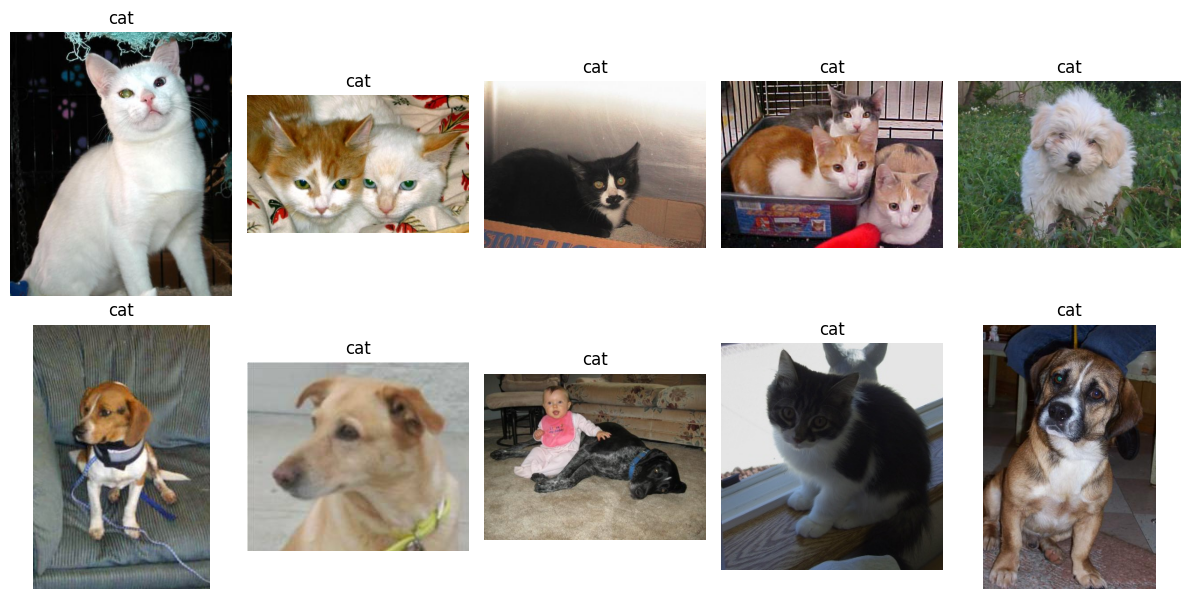

In [136]:
class_ = classes = {0: 'cat', 1: 'dog'}

def display_image_grid(images_filepaths, predicted_labels=(), cols=5):
    rows = len(images_filepaths) // cols
    figure, ax = plt.subplots(rows, cols, figsize=(12, 6))

    for i, image_filepath in enumerate(images_filepaths):
        image = cv2.imread(image_filepath)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        image_id = os.path.splitext(os.path.basename(image_filepath))[0]
        label = res.loc[res['id'] == image_id, 'label'].values[0]

        if label > 0.5:
            label = 1
        else:
            label = 0

        ax.ravel()[i].imshow(image)
        ax.ravel()[i].set_title(class_[label])
        ax.ravel()[i].set_axis_off()

    plt.tight_layout()
    plt.show()

display_image_grid(test_images_filepaths)